<a href="https://colab.research.google.com/github/sampurnashaw/AI-LAB/blob/main/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 2: The Water Jug Problem (Solved using BFS)
Problem Statement:
You are given two jugs: Jug A with a capacity of 4 litres, and Jug B with a capacity of 3 litres. Neither jug has any markings on it. Using only the following operations — (i) fill a jug completely, (ii) empty a jug completely, (iii) pour water from one jug into the other until either the first jug is empty or the second jug is full — determine the minimum sequence of steps needed to measure out exactly 2 litres of water in any one jug.

Solving Water Jug Problem: Jug A = 4L, Jug B = 3L, Target = 2L
Minimum sequence of steps:


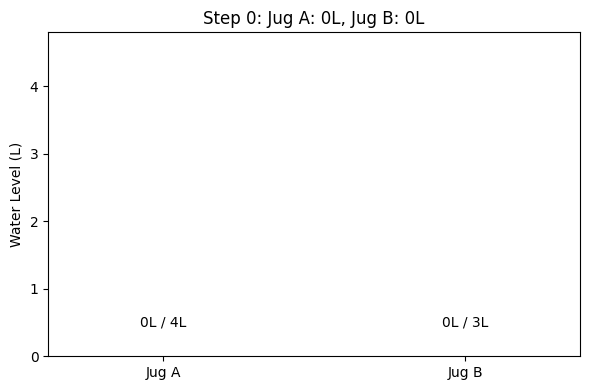

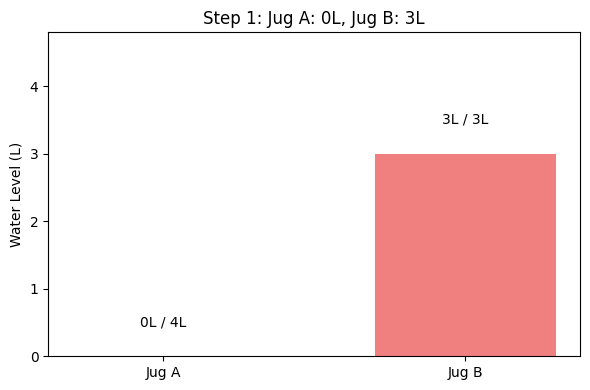

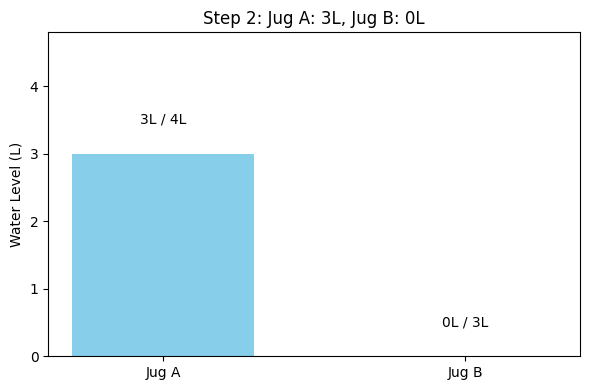

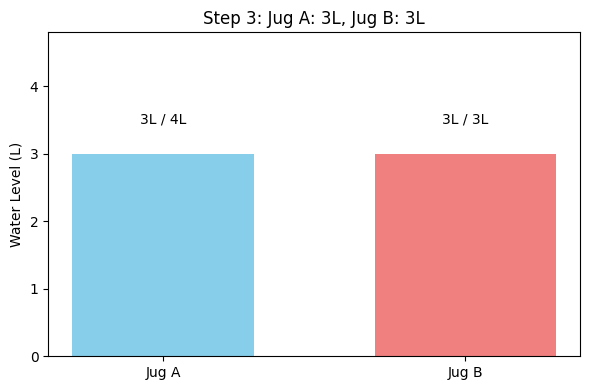

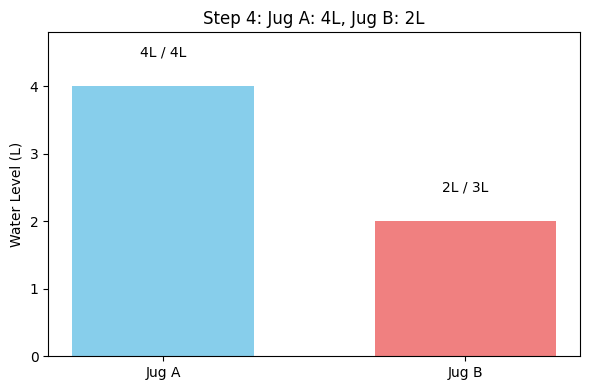

Total steps: 4


In [1]:
from collections import deque
import matplotlib.pyplot as plt

def water_jug_problem_bfs(jug_a_capacity, jug_b_capacity, target):
    """
    Solves the Water Jug Problem using Breadth-First Search (BFS).

    Args:
        jug_a_capacity (int): Capacity of jug A.
        jug_b_capacity (int): Capacity of jug B.
        target (int): The target amount of water to measure.

    Returns:
        list: A list of tuples representing the sequence of states (jug_a, jug_b)
              to reach the target, or None if no solution is found.
    """

    # Queue for BFS, storing (current_state, path_to_state)
    queue = deque([((0, 0), [(0, 0)])])

    # Set to keep track of visited states
    visited = set()
    visited.add((0, 0))

    while queue:
        (jug_a, jug_b), path = queue.popleft()

        # Check if the target is reached
        if jug_a == target or jug_b == target:
            return path

        # Generate next possible states
        next_states = []

        # 1. Fill Jug A
        next_states.append((jug_a_capacity, jug_b))
        # 2. Fill Jug B
        next_states.append((jug_a, jug_b_capacity))
        # 3. Empty Jug A
        next_states.append((0, jug_b))
        # 4. Empty Jug B
        next_states.append((jug_a, 0))

        # 5. Pour A to B
        pour_amount = min(jug_a, jug_b_capacity - jug_b)
        next_states.append((jug_a - pour_amount, jug_b + pour_amount))

        # 6. Pour B to A
        pour_amount = min(jug_b, jug_a_capacity - jug_a)
        next_states.append((jug_a + pour_amount, jug_b - pour_amount))

        for next_a, next_b in next_states:
            if (next_a, next_b) not in visited:
                visited.add((next_a, next_b))
                new_path = path + [(next_a, next_b)]
                queue.append(((next_a, next_b), new_path))

    return None  # No solution found

# Problem parameters
jug_a_capacity = 4
jug_b_capacity = 3
target = 2

print(f"Solving Water Jug Problem: Jug A = {jug_a_capacity}L, Jug B = {jug_b_capacity}L, Target = {target}L")
solution_path = water_jug_problem_bfs(jug_a_capacity, jug_b_capacity, target)

if solution_path:
    print("Minimum sequence of steps:")
    max_capacity = max(jug_a_capacity, jug_b_capacity)
    for i, (a, b) in enumerate(solution_path):
        # Create a figure for each step
        fig, ax = plt.subplots(figsize=(6, 4))
        bars = ax.bar(['Jug A', 'Jug B'], [a, b], color=['skyblue', 'lightcoral'], width=0.6)

        ax.set_ylim(0, max_capacity * 1.2) # Set y-limit slightly above max capacity
        ax.set_ylabel('Water Level (L)')
        ax.set_title(f'Step {i}: Jug A: {a}L, Jug B: {b}L')

        # Add current water level and capacity text on top of bars
        for bar, current_level, capacity in zip(bars, [a, b], [jug_a_capacity, jug_b_capacity]):
            yval = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, yval + 0.1 * max_capacity,
                    f'{current_level}L / {capacity}L', ha='center', va='bottom')

        plt.tight_layout()
        plt.show()
    print(f"Total steps: {len(solution_path) - 1}") # Exclude initial state as a step
else:
    print("No solution found for the given problem.")